In [1]:

from pathlib import Path
import argparse
import numpy as np
import sys

# sys.path.append(r"/users/jpm590/2dspace/post-processing/sdtools")
sys.path.append(r"/Users/zero/workspace/phd_work/hms_output/sdtools")

from hermes3.case_db import *
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *

%matplotlib widget


## Plot puff location

Mesh file /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_lowresol_260513_nowallpump_6e20.nc closed


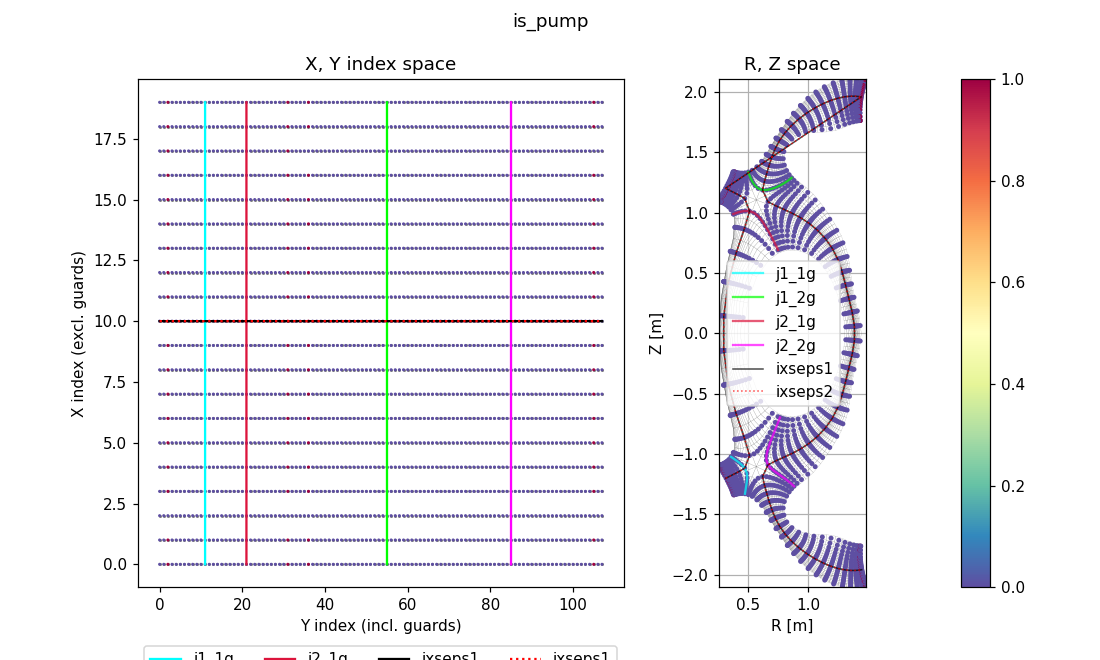

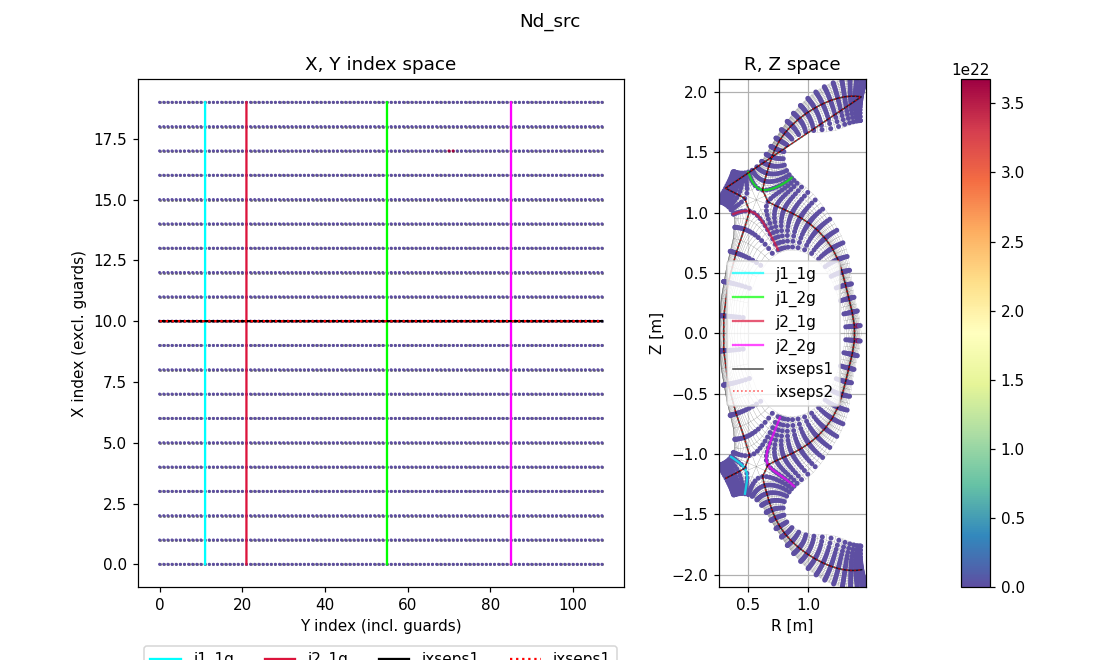

In [ ]:

# 1. Load the grid (.nc file)
# mesh = Mesh("/users/jpm590/gridfile/CDN_46895_260402_expand_puff.nc")
# mesh = Mesh("/users/jpm590/gridfile/CDN_46895_260412_nowallpump_1e20.nc")
# mesh = Mesh("/Users/zero/workspace/phd_work/hms_output/CDN_46895_260412_allpumprec_1e19.nc")
mesh = Mesh("/Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_lowresol_260513_nowallpump_6e20.nc")
# mesh = Mesh("/users/jpm590/gridfile/CDN_46895_260412_allpumprec_1e19.nc")

# mesh = Mesh("/users/jpm590/gridfile/CDN_46895_260408_1e19.nc")
# mesh = Mesh("/users/jpm590/neutralimit_gcc12_9497476/hermes-3/build-mc-master/CDN_46895_260314_nowallpump_3e20.nc")
# mesh = Mesh("/users/jpm590/neutralimit_gcc12_9497476/hermes-3/build-mc-master/CDN_46895_260129_nowallpump_1e21.nc")
# 2. Plot the existing fields in the mesh
mesh.plot_field("Nd_src")
mesh.plot_field("is_pump")
# mesh.plot_field("Pd_src")
# mesh.plot_field("Nd+_src")
# mesh.plot_field("D_d+")
# mesh.plot_field("D_e")
# 3. Always remember to close it!
mesh.close()
plt.show()


polygon 

In the original notebbok from Mike, it was 
```
    Ni_src_core = 0,    # s-1
    Pi_src_core = 0.3e6 * 2/3 * 0,   # W converted to pressure
    Pe_src_core = 0.3e6 * 2/3 * 0,   # W converted to pressure
```
You can see he mean to convert 0.3 MW into Pascal, but then he put it into zero because he can assign the power_in for e and ion in the `BOUT.inp` 

In [ ]:
old_grid_path = r"/users/jpm590/neutralimit_gcc12_9497476/hermes-3/build-mc-master/CDN_46895_260314_nowallpump_3e20.nc"
new_grid_path = r"/users/jpm590/test.nc"
impose_fields(
    old_grid_path,
    new_grid_path,
    Nd_src_puff = 1.3e21,
    Ni_src_core = 0,    # s-1
    Pi_src_core = 0.3e6 * 2/3 * 0,   # W converted to pressure
    Pe_src_core = 0.3e6 * 2/3 * 0,   # W converted to pressure
    D_core = 4,
    chi_core = 10,
    D_sol = 4,
    chi_sol = 4,
)

# Run with NetCDF file

In [ ]:
from scipy.io import netcdf
import netCDF4 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

filepath = "/users/jpm590/neutralrun/hermes-3/master/CDN_46895_260120_nowallpump_2e21.nc"
nc = netCDF4.Dataset(filepath)
list(nc.variables.keys() )

In [ ]:
print(nc["D_d+"])
print(nc["is_pump"][39::])


In [ ]:
fig, ax = plt.subplots()
n=1
m=3
k=1
# Rxy = nc.variables['Rxy'][n:m:k]
Rxy = nc.variables['Rxy_lower_right_corners'][:]
Zxy = nc.variables['Zxy_lower_right_corners'][:]


# print(f"Rxy: {Rxy}")
# Zxy = nc.variables['Zxy'][n:m:k]

# print(f"Zxy: {Zxy}")

ax.scatter(Rxy, Zxy, s=1)
ax.set_xlim(-0.5, 2.0)
# ax.set_ylim(0.0, 2.0)
ax.set_aspect('equal', adjustable='box')
ax.grid()